In [97]:
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import MSTL
import sqlite3
import os
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import root_mean_squared_error


In [98]:
df=pd.read_csv('PJME_hourly.csv')

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [100]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [101]:
df['Datetime']=pd.to_datetime(df['Datetime'],format="ISO8601",errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[ns]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


In [102]:
df['Year']=df['Datetime'].dt.year
df['Month']=df['Datetime'].dt.month
df['Day']=df['Datetime'].dt.day
df['dayofweek'] = df['Datetime'].dt.dayofweek
df['hour']=df['Datetime'].dt.hour
df.head()

,Datetime,PJME_MW,Year,Month,Day,dayofweek,hour
0,2002-12-31 01:00:00,26498.0,2002,12,31,1,1
1,2002-12-31 02:00:00,25147.0,2002,12,31,1,2
2,2002-12-31 03:00:00,24574.0,2002,12,31,1,3
3,2002-12-31 04:00:00,24393.0,2002,12,31,1,4
4,2002-12-31 05:00:00,24860.0,2002,12,31,1,5


In [103]:
full_range = pd.date_range(start=df['Datetime'].min(), end=df['Datetime'].max(), freq='H')
missing_hours = full_range.difference(df['Datetime'])
len(missing_hours)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10620\1673375239.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df['Datetime'].min(), end=df['Datetime'].max(), freq='H')


30

In [104]:
missing_hours

DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00',
               '2007-03-11 03:00:00', '2007-11-04 02:00:00',
               '2008-03-09 03:00:00', '2008-11-02 02:00:00',
               '2009-03-08 03:00:00', '2009-11-01 02:00:00',
               '2010-03-14 03:00:00', '2010-11-07 02:00:00',
               '2010-12-10 00:00:00', '2011-03-13 03:00:00',
               '2011-11-06 02:00:00', '2012-03-11 03:00:00',
               '2012-11-04 02:00:00', '2013-03-10 03:00:00',
               '2013-11-03 02:00:00', '2014-03-09 03:00:00',
               '2015-03-08 03:00:00', '2016-03-13 03:00:00',
               '2017-03-12 03:00:00', '2018-03-11 03:00:00'],
              dtype='datetime64[ns]', freq=None)

In [105]:
df['Datetime'].duplicated().sum()

4

Since there are only 4 duplicate rows we can safely drop it from the table


In [106]:
df['Datetime'].drop_duplicates(inplace=True)

In [107]:
df['PJME_MW'].describe()

count    145366.000000
mean      32080.222831
std        6464.012166
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64

In [108]:
df[df['PJME_MW'] == df['PJME_MW'].min()]

,Datetime,PJME_MW,Year,Month,Day,dayofweek,hour
89117,2012-10-30 04:00:00,14544.0,2012,10,30,1,4


Although all 75% of days had PJME_MW around 35650.000000 on 2006-08-02 we see a sharp spike then usual the usage being higher than 75% the entire day and peaking at the max value of 62009 after which the consumption reduced slowly

# EDA

## Checking the trend of power supply usage across all years


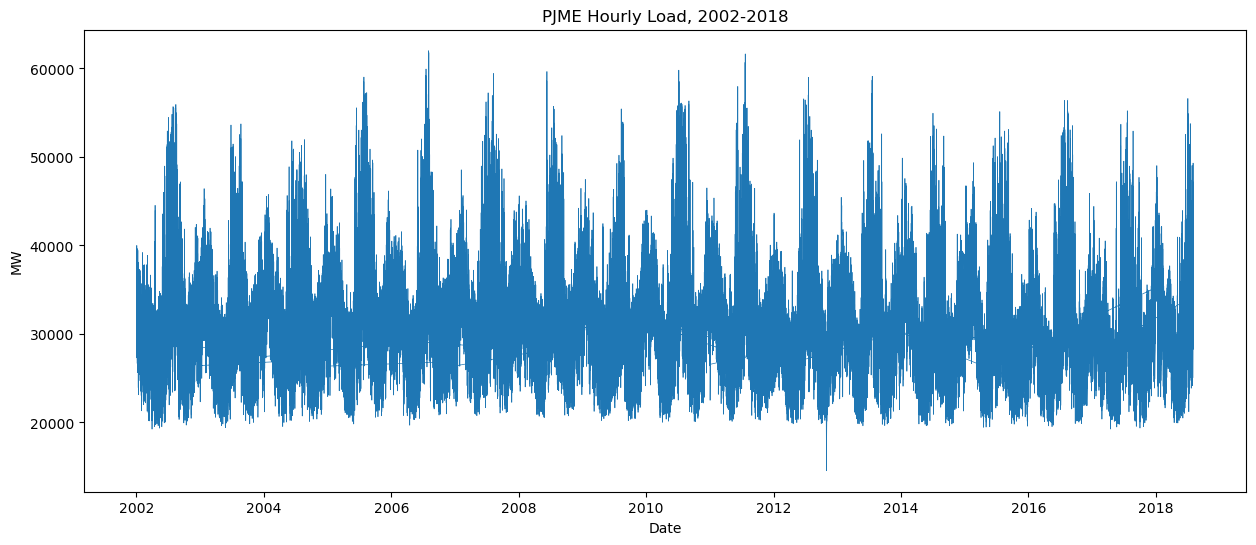

In [109]:
plt.figure(figsize=(15,6))
plt.plot(df['Datetime'], df['PJME_MW'], linewidth=0.5)
plt.title('PJME Hourly Load, 2002-2018')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()

## Observation

The full 16-year hourly load series (2002–2018) shows consistent annual seasonality, with recurring summer peaks and winter/spring troughs visible across every year in the range. Peak and trough magnitudes appear visually stable year-over-year, suggesting no obvious long-term trend, though this cannot be confirmed from raw visual inspection alone given the scale of seasonal variation relative to any potential underlying trend — a rolling annual mean or formal decomposition is needed to verify this before treating it as a finding. One clear anomaly is visible: a sharp, isolated drop in load near the 2012–2013 boundary, falling well below the normal seasonal trough band, which warrants investigation into its exact date and cause before being classified as either a genuine event or a data quality issue.

In [110]:
df[(df['Datetime']>'2012-10-30')&(df['Datetime']<'2012-10-31')]

,Datetime,PJME_MW,Year,Month,Day,dayofweek,hour
89114,2012-10-30 01:00:00,15390.0,2012,10,30,1,1
89115,2012-10-30 02:00:00,14955.0,2012,10,30,1,2
89116,2012-10-30 03:00:00,14586.0,2012,10,30,1,3
89117,2012-10-30 04:00:00,14544.0,2012,10,30,1,4
89118,2012-10-30 05:00:00,14821.0,2012,10,30,1,5
89119,2012-10-30 06:00:00,15526.0,2012,10,30,1,6
89120,2012-10-30 07:00:00,16688.0,2012,10,30,1,7
89121,2012-10-30 08:00:00,17734.0,2012,10,30,1,8
89122,2012-10-30 09:00:00,18675.0,2012,10,30,1,9
89123,2012-10-30 10:00:00,19775.0,2012,10,30,1,10


<Axes: xlabel='Month'>

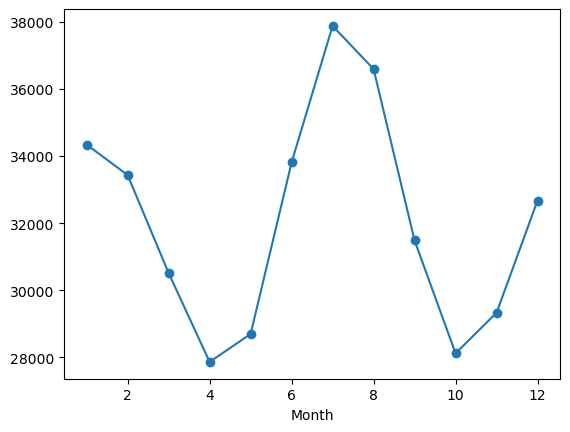

In [111]:
df.groupby('Month')['PJME_MW'].mean().plot(marker='o')

## Observation
Monthly seasonal averages confirm a dominant summer peak (July, ~38,000 MW) with a secondary, smaller winter peak (January, ~34,300 MW), separated by clear shoulder-season troughs in April and October (~27,800–29,300 MW). This dual-peak, asymmetric seasonal pattern is consistent with combined cooling (summer) and heating (winter) demand drivers, with cooling load being the larger contributor.

<Axes: xlabel='Year'>

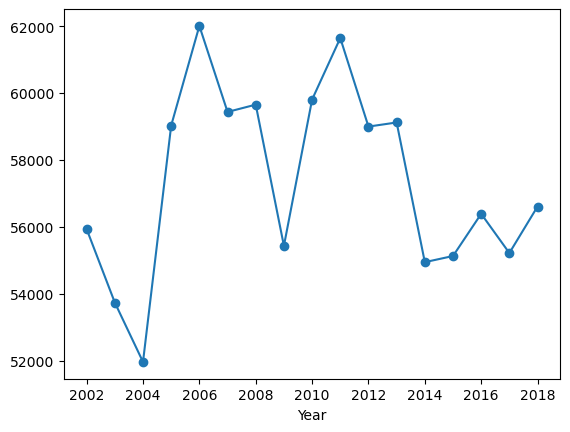

In [112]:
df.groupby('Year')['PJME_MW'].max().plot(marker='o')

## Observation
Annual peak load magnitude (2002–2018) shows substantial year-to-year variation, ranging from ~52,000 MW (2004) to ~62,000 MW (2006) — a swing of roughly 19%. This disproves the earlier finding that "power consumption has not really increased over time," which was based on visual inspection of the compressed 16-year raw series and incorrectly read peak/trough stability where none exists. The corrected picture: there is no clear monotonic long-term trend (peaks don't consistently rise or fall across the period), but this is because year-to-year magnitude is highly volatile — likely weather-driven (hotter/colder years) — not because consumption is genuinely flat. Years like 2006 and 2011 show comparably high peaks despite being five years apart, while 2004 and 2014 are both low points a decade apart, indicating the variation is not structural or directional but driven by external, year-specific factors.

<Axes: xlabel='dayofweek'>

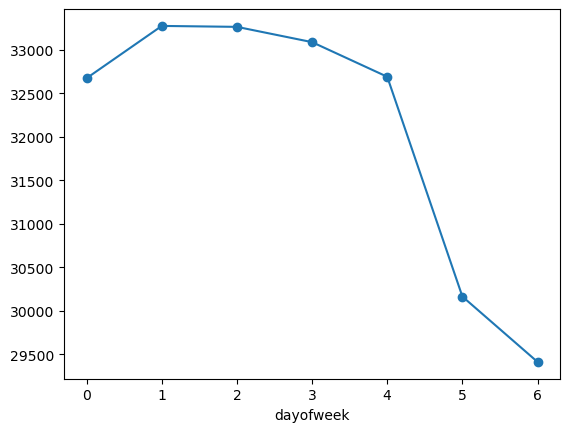

In [113]:
df.groupby('dayofweek')['PJME_MW'].mean().plot(marker='o')

## Observation
Load by day-of-week shows a clear split between weekdays (Mon–Fri) and weekends (Sat–Sun): Tuesday and Wednesday are highest (~33,300 MW), with Thursday and Monday close behind, before a sharp drop on Saturday (~30,200 MW) and an even lower Sunday (~29,400 MW). Monday is also notably lower than Tue–Thu despite being a weekday — a departure from the otherwise flat weekday plateau that warrants further investigation.

### Creating a holiday flag

In [114]:

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df['Datetime'].min(), end=df['Datetime'].max())

In [115]:
df['is_holiday']=df['Datetime'].dt.normalize().isin(holidays)

In [116]:
df.groupby('is_holiday')['PJME_MW'].mean()

is_holiday
False    32106.176009
True     31147.662348
Name: PJME_MW, dtype: float64

In [117]:
df[df['dayofweek'] < 5].groupby('is_holiday')['PJME_MW'].mean()

is_holiday
False    33068.894271
True     31147.662348
Name: PJME_MW, dtype: float64

## Observation


It is observed that holidays bring down power consumption, but the effect is not as drastic as the weekend vs. weekday shift. The reason could be that not all companies are closed on many holidays included in the USFederalHolidayCalendar (e.g., federal-only holidays like Columbus Day or Veterans Day, which government/banks observe but many private employers don't).

## Checking effects of seasons on power consumption


In [118]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
df['Season']=df['Month'].apply(get_season)


<Axes: xlabel='Season'>

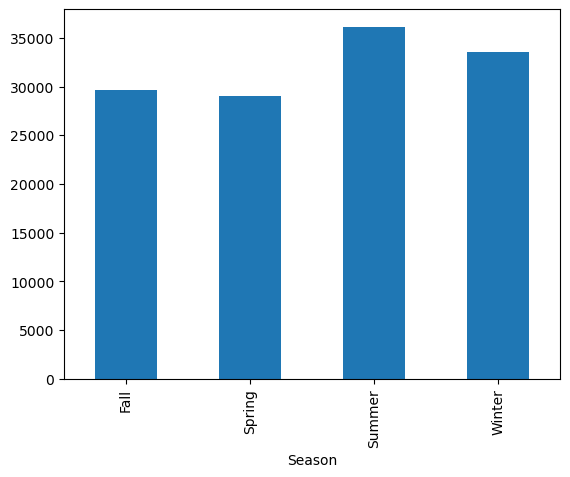

In [119]:
df.groupby('Season')['PJME_MW'].mean().plot(kind='bar')

## Observation

Average load by season shows Summer clearly highest (~36,100 MW), followed by Winter (~33,500 MW), with Fall and Spring both substantially lower and close to each other (~29,600 and ~29,000 MW respectively). This confirms the dual-peak pattern already seen in the monthly breakdown — summer cooling demand is the dominant driver, winter heating is a secondary but real peak, and both shoulder seasons sit well below either.

## Power Usage categorized based on time of day


<Axes: title={'center': 'Average Power Consumption Across Time of Day'}, xlabel='hour'>

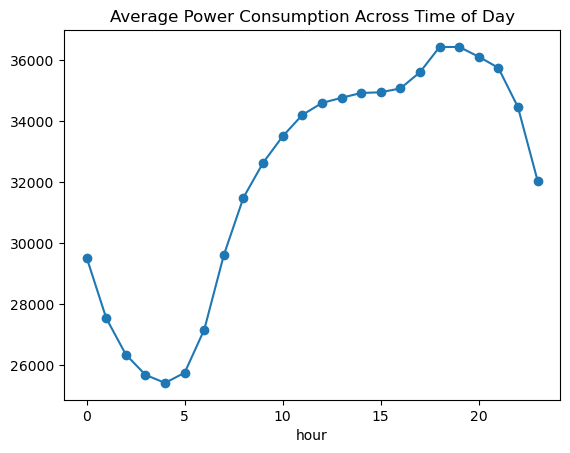

In [120]:
plt.title("Average Power Consumption Across Time of Day")
df.groupby('hour')['PJME_MW'].mean().plot(marker='o')

## Observation
Average load by hour shows a clear daily cycle: a trough around 4–5 AM (~25,400 MW), a steady ramp from ~6 AM, rising into a broad plateau from roughly 11 AM to 9 PM (~34,500–36,500 MW), with the peak sitting around 6–7 PM (hours 17–19) rather than a sharp single-hour spike, followed by a decline through the late evening back toward the overnight trough.

## Checking hourly power consumption across diffrent seasons

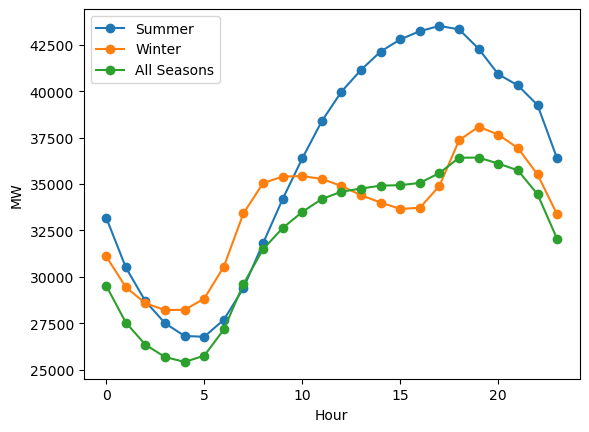

In [121]:
summer_hourly = df[df['Season']=='Summer'].groupby('hour')['PJME_MW'].mean()
winter_hourly = df[df['Season']=='Winter'].groupby('hour')['PJME_MW'].mean()
all_hourly = df.groupby('hour')['PJME_MW'].mean()
plt.plot(summer_hourly.index, summer_hourly.values, marker='o', label='Summer')
plt.plot(winter_hourly.index, winter_hourly.values, marker='o', label='Winter')
plt.plot(all_hourly.index,all_hourly.values,marker='o',label='All Seasons')
plt.xlabel('Hour')
plt.ylabel('MW')
plt.legend()
plt.show()

## Observation
Overlaying Summer, Winter, and the All Seasons baseline on the same hourly axis shows that the two seasons follow genuinely different intraday shapes, not just different overall levels. Summer follows a broad, single-peak curve — a steady rise from the early-morning trough through the afternoon, peaking around 5–7 PM (~43,000 MW), then declining. Winter instead shows a dual-peak pattern: a moderate morning peak (~9–10 AM, ~35,300 MW), a slight mid-day dip, and a sharper evening peak (~7 PM, ~38,000 MW) that exceeds the morning one. Winter is actually higher than Summer during the early-morning hours (roughly midnight–7 AM), consistent with heating demand dominating before cooling demand ramps up later in the day. The All Seasons line sits below both across most hours (since it also includes lower-consumption Spring and Fall), but its shape shifts — tracking closer to Winter in the early morning and closer to Summer through the afternoon/evening — confirming it's a blended average that obscures the two seasons' distinct underlying patterns.

## Is the series Non-Stationary

In [122]:
result = adfuller(df['PJME_MW'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -18.828912729084053
p-value: 2.022124508152674e-30


## Observation
Since p-value is very small we fail to reject our null hypothesis that the series is a non-stationary data

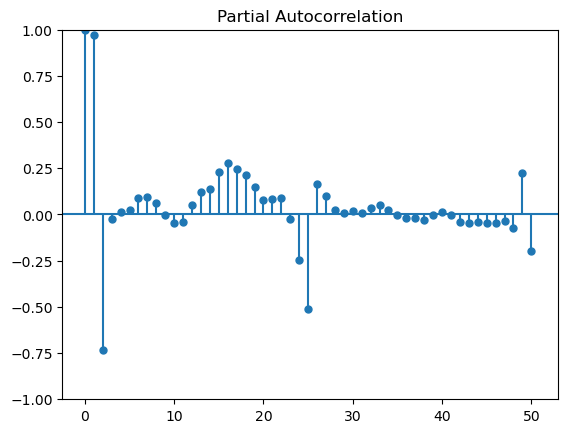

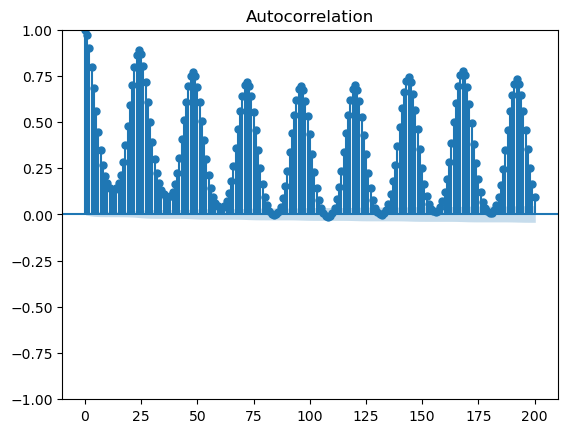

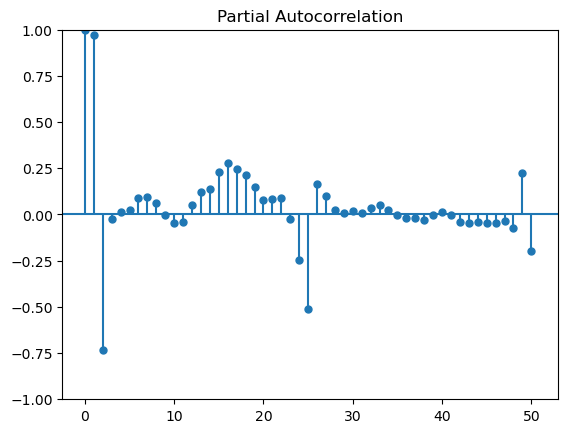

In [123]:

plot_acf(df['PJME_MW'], lags=200)
plot_pacf(df['PJME_MW'], lags=50)

## Observation
ACF (lags 0–200) shows a clear repeating wave with peaks every ~24 lags, confirming a strong daily cycle. Peaks decay slowly — the lag-168 peak (weekly) is still strongly elevated (~0.6–0.7), confirming a real weekly cycle too. Troughs near zero occur at ~12-hour offsets (least similar point in the cycle).

PACF (lags 0–50) isolates direct effects only: a very strong lag-1 effect (~0.98) with a sharp negative correction at lag 2 (~-0.73), a moderate cluster around lag 14–19, and a notable negative spike at lag 24–25 (~-0.5) — confirming lag 24 has a real direct effect, but not a simple positive "yesterday repeats" relationship.

Reading together: ACF shows strong cumulative daily/weekly persistence; PACF shows most direct predictive power sits at lag 1, with lag 24 adding a genuine but non-trivial (partly corrective) effect on top.

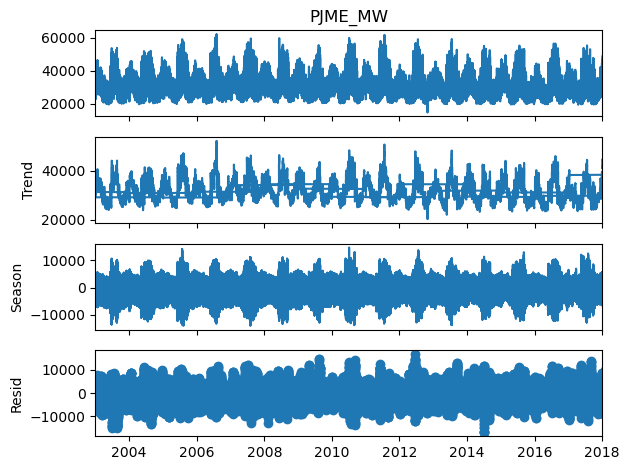

In [124]:
stl = STL(df.set_index('Datetime')['PJME_MW'], period=24, robust=True)
result = stl.fit()
result.plot()
plt.show()

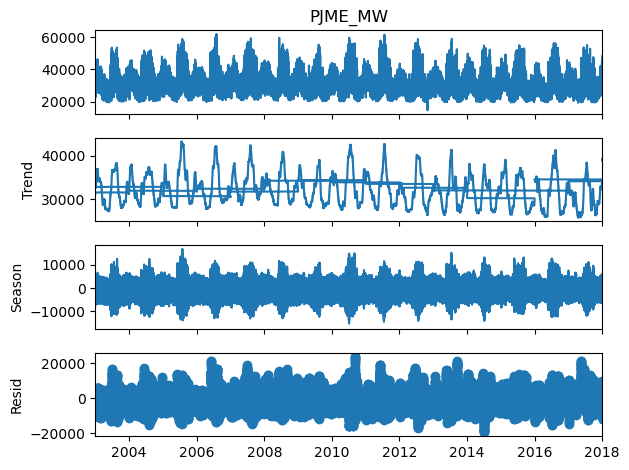

In [125]:
stl = STL(df.set_index('Datetime')['PJME_MW'], period=24, trend=24*21+1, robust=True)
result = stl.fit()
result.plot()
plt.show()

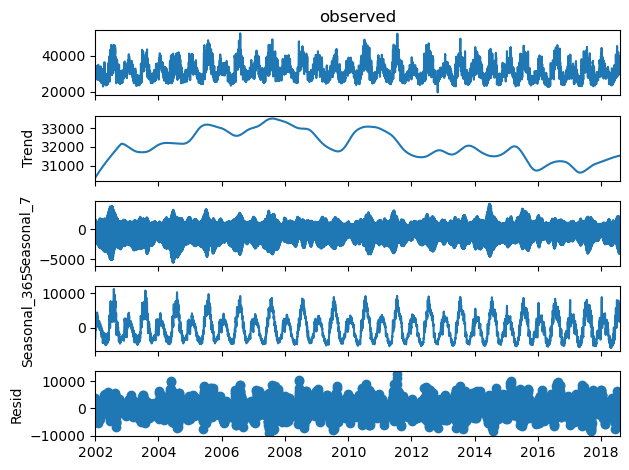

In [126]:
daily = df.set_index('Datetime')['PJME_MW'].resample('D').mean()
mstl = MSTL(daily, periods=[7, 365])
result = mstl.fit()
result.plot()
plt.show()

## Observation
MSTL decomposition on daily-averaged load (periods=7, 365) produces a clean, interpretable split, unlike the earlier single-period STL attempt where the trend line was contaminated by unmodeled annual seasonality. The trend component is now genuinely smooth, oscillating gently between ~30,500–33,500 MW over multi-year spans with no clear sustained long-term rise or fall — consistent with the earlier annual-peaks finding of high volatility without directional trend. The annual seasonal component clearly captures the summer/winter cycle already established via monthly averages, while the weekly seasonal component is visibly smaller in amplitude, confirming the weekday/weekend effect is real but secondary to annual seasonality. The residual component shows generally consistent noise with several visible taller spikes at specific points (e.g., near 2010–2011) — these are candidate anomaly points once trend and both seasonal cycles are properly accounted for, and represent the closest available proxy to "unexplained" variation in the series.

In [127]:
result.resid.loc['2006-08-01':'2006-08-05']

Datetime
2006-08-01    6275.037386
2006-08-02    8411.277105
2006-08-03    8646.279741
2006-08-04    5377.665647
2006-08-05    3855.195558
Freq: D, Name: resid, dtype: float64

# Creating a Database

In [128]:
df.head()
df.dropna(inplace=True)

In [129]:
print("DataFrame shape:", df.shape)
print("DataFrame columns:", df.columns.tolist())

conn = sqlite3.connect("pjme_load.db")

df.to_sql(
    "load_data",
    conn,
    if_exists="replace",
    index=False
)

print(
    pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )
)

print("Rows in database:", pd.read_sql(
    "SELECT *  FROM load_data;",
    conn
))

conn.close()

print("File size:", os.path.getsize("pjme_load.db"), "bytes")

DataFrame shape: (145366, 9)
DataFrame columns: ['Datetime', 'PJME_MW', 'Year', 'Month', 'Day', 'dayofweek', 'hour', 'is_holiday', 'Season']
                 name
0          train_data
1            val_data
2           test_data
3   test_anomaly_data
4  train_anomaly_data
5    val_anomaly_data
6        anomaly_data
7           load_data
Rows in database:                    Datetime  PJME_MW  Year  Month  Day  dayofweek  hour  \
0       2002-12-31 01:00:00  26498.0  2002     12   31          1     1   
1       2002-12-31 02:00:00  25147.0  2002     12   31          1     2   
2       2002-12-31 03:00:00  24574.0  2002     12   31          1     3   
3       2002-12-31 04:00:00  24393.0  2002     12   31          1     4   
4       2002-12-31 05:00:00  24860.0  2002     12   31          1     5   
...                     ...      ...   ...    ...  ...        ...   ...   
145361  2018-01-01 20:00:00  44284.0  2018      1    1          0    20   
145362  2018-01-01 21:00:00  43751.0  2018 

In [130]:
import os
import sqlite3

print("Working directory:", os.getcwd())
print("Database path:", os.path.abspath("pjme.db"))
print("Database exists:", os.path.exists("pjme.db"))

Working directory: c:\Users\LENOVO\OneDrive\Desktop\python\PJME Project
Database path: c:\Users\LENOVO\OneDrive\Desktop\python\PJME Project\pjme.db
Database exists: True


# Feature Engineering


In [131]:
conn = sqlite3.connect('pjme_load.db')
raw = pd.read_sql('SELECT * FROM load_data', conn)
conn.close()


In [132]:
df.head()

,Datetime,PJME_MW,Year,Month,Day,dayofweek,hour,is_holiday,Season
0,2002-12-31 01:00:00,26498.0,2002,12,31,1,1,False,Winter
1,2002-12-31 02:00:00,25147.0,2002,12,31,1,2,False,Winter
2,2002-12-31 03:00:00,24574.0,2002,12,31,1,3,False,Winter
3,2002-12-31 04:00:00,24393.0,2002,12,31,1,4,False,Winter
4,2002-12-31 05:00:00,24860.0,2002,12,31,1,5,False,Winter


In [133]:
# Lag Feautres
df_model=df.sort_values('Datetime').reset_index(drop=True).copy()
df_model['lag_1']=df_model['PJME_MW'].shift(1)
df_model['lag_24']=df_model['PJME_MW'].shift(24)
df_model['lag_168']=df_model['PJME_MW'].shift(168)
df_model['is_weekend']=df_model['dayofweek'].isin([5, 6]).astype(int)
df_model.drop(columns=['Year','Season'],inplace=True)

In [134]:
df_model.dropna(inplace=True)

In [135]:
df.isna().sum()

Datetime      0
PJME_MW       0
Year          0
Month         0
Day           0
dayofweek     0
hour          0
is_holiday    0
Season        0
dtype: int64

In [136]:
df_model.isna().sum()

Datetime      0
PJME_MW       0
Month         0
Day           0
dayofweek     0
hour          0
is_holiday    0
lag_1         0
lag_24        0
lag_168       0
is_weekend    0
dtype: int64

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Datetime    145366 non-null  datetime64[ns]
 1   PJME_MW     145366 non-null  float64       
 2   Year        145366 non-null  int32         
 3   Month       145366 non-null  int32         
 4   Day         145366 non-null  int32         
 5   dayofweek   145366 non-null  int32         
 6   hour        145366 non-null  int32         
 7   is_holiday  145366 non-null  bool          
 8   Season      145366 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(1), int32(5), object(1)
memory usage: 6.2+ MB


In [138]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145198 entries, 168 to 145365
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Datetime    145198 non-null  datetime64[ns]
 1   PJME_MW     145198 non-null  float64       
 2   Month       145198 non-null  int32         
 3   Day         145198 non-null  int32         
 4   dayofweek   145198 non-null  int32         
 5   hour        145198 non-null  int32         
 6   is_holiday  145198 non-null  bool          
 7   lag_1       145198 non-null  float64       
 8   lag_24      145198 non-null  float64       
 9   lag_168     145198 non-null  float64       
 10  is_weekend  145198 non-null  int32         
dtypes: bool(1), datetime64[ns](1), float64(4), int32(5)
memory usage: 9.6 MB


# Model Training


In [139]:
from sklearn.ensemble import IsolationForest

feature_cols = ['PJME_MW', 'lag_1', 'lag_24', 'lag_168',
                 'hour', 'dayofweek', 'is_weekend', 'Month', 'is_holiday']

X = df_model[feature_cols]

model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

model.fit(X)
df_model['anomaly_score'] = model.decision_function(X)   
df_model['is_anomaly'] = model.predict(X)      
df_model['Year']=df['Year']
df_model['Season']=df['Season']

In [140]:
df_model

,Datetime,PJME_MW,Month,Day,dayofweek,hour,is_holiday,lag_1,lag_24,lag_168,is_weekend,anomaly_score,is_anomaly,Year,Season
168,2002-01-08 01:00:00,29445.0,1,8,1,1,False,31187.0,26862.0,30393.0,0,0.135033,1,2002,Winter
169,2002-01-08 02:00:00,28670.0,1,8,1,2,False,29445.0,25976.0,29265.0,0,0.139365,1,2002,Winter
170,2002-01-08 03:00:00,28375.0,1,8,1,3,False,28670.0,25641.0,28357.0,0,0.129193,1,2002,Winter
171,2002-01-08 04:00:00,28542.0,1,8,1,4,False,28375.0,25666.0,27899.0,0,0.127367,1,2002,Winter
172,2002-01-08 05:00:00,29261.0,1,8,1,5,False,28542.0,26328.0,28057.0,0,0.141060,1,2002,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145361,2018-08-02 20:00:00,44057.0,8,2,3,20,False,45641.0,46912.0,46337.0,0,0.093070,1,2018,Winter
145362,2018-08-02 21:00:00,43256.0,8,2,3,21,False,44057.0,45985.0,44542.0,0,0.104891,1,2018,Winter
145363,2018-08-02 22:00:00,41552.0,8,2,3,22,False,43256.0,44094.0,42638.0,0,0.110983,1,2018,Winter
145364,2018-08-02 23:00:00,38500.0,8,2,3,23,False,41552.0,40666.0,39276.0,0,0.124732,1,2018,Winter


In [141]:
print("DataFrame shape:", df.shape)
print("DataFrame columns:", df.columns.tolist())

conn = sqlite3.connect("pjme_load.db")
df.to_sql(
    "load_data",
    conn,
    if_exists="replace",
    index=False
)
df_model.to_sql('anomaly_data', conn, if_exists='replace', index=False)

print(
    pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )
)

print("Rows in database:", pd.read_sql(
    "SELECT *  FROM anomaly_data;",
    conn
))

conn.close()

print("File size:", os.path.getsize("pjme_load.db"), "bytes")

DataFrame shape: (145366, 9)
DataFrame columns: ['Datetime', 'PJME_MW', 'Year', 'Month', 'Day', 'dayofweek', 'hour', 'is_holiday', 'Season']
                 name
0          train_data
1            val_data
2           test_data
3   test_anomaly_data
4  train_anomaly_data
5    val_anomaly_data
6           load_data
7        anomaly_data
Rows in database:                    Datetime  PJME_MW  Month  Day  dayofweek  hour  is_holiday  \
0       2002-01-08 01:00:00  29445.0      1    8          1     1           0   
1       2002-01-08 02:00:00  28670.0      1    8          1     2           0   
2       2002-01-08 03:00:00  28375.0      1    8          1     3           0   
3       2002-01-08 04:00:00  28542.0      1    8          1     4           0   
4       2002-01-08 05:00:00  29261.0      1    8          1     5           0   
...                     ...      ...    ...  ...        ...   ...         ...   
145193  2018-08-02 20:00:00  44057.0      8    2          3    20           

In [142]:
df_model

,Datetime,PJME_MW,Month,Day,dayofweek,hour,is_holiday,lag_1,lag_24,lag_168,is_weekend,anomaly_score,is_anomaly,Year,Season
168,2002-01-08 01:00:00,29445.0,1,8,1,1,False,31187.0,26862.0,30393.0,0,0.135033,1,2002,Winter
169,2002-01-08 02:00:00,28670.0,1,8,1,2,False,29445.0,25976.0,29265.0,0,0.139365,1,2002,Winter
170,2002-01-08 03:00:00,28375.0,1,8,1,3,False,28670.0,25641.0,28357.0,0,0.129193,1,2002,Winter
171,2002-01-08 04:00:00,28542.0,1,8,1,4,False,28375.0,25666.0,27899.0,0,0.127367,1,2002,Winter
172,2002-01-08 05:00:00,29261.0,1,8,1,5,False,28542.0,26328.0,28057.0,0,0.141060,1,2002,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145361,2018-08-02 20:00:00,44057.0,8,2,3,20,False,45641.0,46912.0,46337.0,0,0.093070,1,2018,Winter
145362,2018-08-02 21:00:00,43256.0,8,2,3,21,False,44057.0,45985.0,44542.0,0,0.104891,1,2018,Winter
145363,2018-08-02 22:00:00,41552.0,8,2,3,22,False,43256.0,44094.0,42638.0,0,0.110983,1,2018,Winter
145364,2018-08-02 23:00:00,38500.0,8,2,3,23,False,41552.0,40666.0,39276.0,0,0.124732,1,2018,Winter


In [143]:
df_model['is_anomaly'].value_counts()

is_anomaly
 1    143746
-1      1452
Name: count, dtype: int64

## Observartion
Filtering to only the anomaly-flagged hours during Aug 1–5, 2006 shows a clean, interpretable pattern: flagged hours consistently cluster in the afternoon/evening (~11am–10pm) across all five days, aligning with peak cooling-demand hours during a heat wave. The most negative (most anomalous) scores occur on Aug 2–3, matching the peak severity window independently confirmed via the earlier MSTL residual check (~8,646 MW residual on Aug 3). Anomaly intensity visibly tapers by Aug 4–5 as load levels decline, consistent with the heat wave subsiding. Nighttime hours within the same days are correctly excluded from flagging. This agreement between two independent methods — decomposition residual and Isolation Forest anomaly score — on the same peak period provides strong confidence the model captures genuine, meaningful anomalies rather than arbitrary statistical noise.

In [144]:
df_model[(df_model['Datetime'] >= "2006-08-01") & (df_model['Datetime'] < "2006-08-06") & (df_model['is_anomaly']==-1)][['Datetime','PJME_MW','anomaly_score']]

,Datetime,PJME_MW,anomaly_score
40154,2006-08-01 12:00:00,56302.0,-0.010294
40155,2006-08-01 13:00:00,58397.0,-0.010729
40156,2006-08-01 14:00:00,60028.0,-0.016895
40157,2006-08-01 15:00:00,61004.0,-0.019019
40158,2006-08-01 16:00:00,61366.0,-0.019009
40159,2006-08-01 17:00:00,61643.0,-0.018442
40160,2006-08-01 18:00:00,61155.0,-0.017199
40161,2006-08-01 19:00:00,60047.0,-0.012949
40162,2006-08-01 20:00:00,58673.0,-0.009477
40163,2006-08-01 21:00:00,58093.0,-0.008773


## Observation

Validating against the known Aug 2006 heat wave event: filtering to only anomaly-flagged hours during Aug 1–5 shows the model consistently flags afternoon/evening hours (~11am–10pm) across all five days, with the most negative (most anomalous) scores concentrated on Aug 2–3 — matching the peak severity window independently identified via the MSTL residual check. Nighttime hours within the same days are correctly not flagged, and anomaly intensity visibly tapers by Aug 4–5 as the event subsides. This cross-validates two independent methods (decomposition residual and Isolation Forest score) converging on the same peak period, giving strong confidence the model is capturing genuinely meaningful anomalies rather than arbitrary noise.

In [145]:
df_model.groupby('is_anomaly')[feature_cols].mean()

,PJME_MW,lag_1,lag_24,lag_168,hour,dayofweek,is_weekend,Month,is_holiday
is_anomaly,,,,,,,,,
-1,45323.710055,45310.917355,44764.400138,40928.409780,13.52686,2.453857,0.285813,6.338154,0.342287
1,31945.934962,31946.034276,31950.571049,31986.405083,11.48114,3.004508,0.285448,6.443289,0.023924


## Observation
Comparing average feature values between anomalous and normal points shows anomalies are strongly associated with elevated load: PJME_MW, lag_1, and lag_24 are all substantially higher for anomalies (~45,300 vs ~31,950 MW), indicating anomalous points involve genuinely high demand, not just unusual timing. Notably, lag_168 shows a smaller relative gap (~40,928 vs ~31,986) than lag_1/lag_24, suggesting flagged anomalies deviate more sharply from very recent history (last hour, last day) than from the same period a week earlier — i.e., the model is catching sudden short-term deviations more than departures from the weekly pattern. is_holiday shows a large relative gap (0.342 vs 0.024), indicating anomalies disproportionately occur on holidays. is_weekend shows no meaningful difference between groups (0.286 vs 0.285), which is expected — it functions as a context feature that helps the model correctly define "normal" separately for weekdays/weekends, rather than a feature that itself signals anomalous behavior.

## Seasonal-Naive Baseline for Forecasting


In [146]:
conn = sqlite3.connect('pjme_load.db')
val_data = pd.read_sql('SELECT * FROM val_data', conn)
train_data=pd.read_sql('Select * from train_data',conn)
conn.close()
train_data['Datetime'] = pd.to_datetime(train_data['Datetime'])
val_data['Datetime'] = pd.to_datetime(val_data['Datetime'])

In [147]:
val_actual=val_data['PJME_MW']
val_pred_24=val_data['lag_24']
val_pred_168=val_data['lag_168']

In [148]:
mae_24=mean_absolute_error(val_actual, val_pred_24)
mae_168=mean_absolute_error(val_actual, val_pred_168)

rmse_24=root_mean_squared_error(val_actual,val_pred_24)
rmse_168=root_mean_squared_error(val_actual,val_pred_168)

print("MAE Scores on 24 Hour lag is:",mae_24)
print("MAE Scores on 168 Hour Lag is:",mae_168,"\n")

print("--"*50,"\n")

print("RMSE Scores on 24 Hour lag is:",rmse_24)
print("RMSE Scores on 168 Hour Lag is:",rmse_168)

MAE Scores on 24 Hour lag is: 2136.771006726713
MAE Scores on 168 Hour Lag is: 3313.0202371451373 

---------------------------------------------------------------------------------------------------- 

RMSE Scores on 24 Hour lag is: 2935.7519008606096
RMSE Scores on 168 Hour Lag is: 4525.322629830809


## Seasonal-Naive Baseline: Previous-Day vs. Previous-Week

**Observation 1 —** lag_24 beats lag_168 by a wide margin on both MAE (2,136.77 
vs. 3,313.02) and RMSE (2,935.75 vs. 4,525.32) — lag_168's errors are ~55% larger 
on both metrics.

**Observation 2 —** The RMSE/MAE ratio is nearly identical between the two 
(~1.37 each), meaning lag_168's weakness is a general, evenly-distributed effect 
rather than concentrated in extreme misses.

**Formal conclusion:** The previous-day naive baseline (lag_24) substantially 
outperformed the previous-week naive baseline (lag_168) on both MAE and RMSE, 
with lag_168 producing errors approximately 55% larger on both metrics. The 
consistent RMSE-to-MAE ratio across both baselines (~1.37) indicates lag_168's 
degraded performance is distributed relatively uniformly rather than driven by 
a small number of large tail errors, suggesting daily continuity is a 
substantially stronger raw predictor of hourly load than weekly continuity for 
this series.

## Training Baseline XGBoost model 

In [149]:
target='PJME_MW'

BASELINE_FEATURES = ['lag_1', 'lag_24', 'lag_168',
                      'hour', 'dayofweek', 'is_weekend', 'Month', 'is_holiday']

ANOMALY_FEATURES = BASELINE_FEATURES + [
    'anomaly_score', 'anomaly_score_24h_mean', 'anomaly_score_24h_max'
]

In [150]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error 

In [151]:
def train_and_evaluate(train, val, feature_cols, label):
    model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
    model.fit(train[feature_cols], train[target])
    val = val.copy()
    val['predicted'] = model.predict(val[feature_cols])
    mae = mean_absolute_error(val[target], val['predicted'])
    rmse = np.sqrt(mean_squared_error(val[target], val['predicted']))
    val['year_month'] = val['Datetime'].dt.to_period('M')
    monthly = val.groupby('year_month').apply(
        lambda g: pd.Series({
            'MAE': mean_absolute_error(g[target], g['predicted']),
            'RMSE': np.sqrt(mean_squared_error(g[target], g['predicted']))
        })
    ).reset_index()

    return model, {'mae': mae, 'rmse': rmse, 'monthly': monthly}

In [152]:
baseline_model, baseline_results = train_and_evaluate(train_data, val_data, BASELINE_FEATURES,"Baseline")
print(f"Baseline  MAE: {baseline_results['mae']:.2f}   RMSE: {baseline_results['rmse']:.2f}")
baseline_results['monthly']

Baseline  MAE: 320.15   RMSE: 429.59


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10620\712705000.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly = val.groupby('year_month').apply(


,year_month,MAE,RMSE
0,2015-01,286.752733,374.249014
1,2015-02,408.965236,555.739641
2,2015-03,326.980153,442.023919
3,2015-04,274.085286,358.303928
4,2015-05,316.507104,422.390884
5,2015-06,306.820462,421.736488
6,2015-07,342.033046,454.015605
7,2015-08,342.085746,449.621799
8,2015-09,338.513162,452.147307
9,2015-10,267.691396,359.896253


## Anomaly Aware XGBoost Model

In [153]:
def anamoly_data(table_name):
    conn = sqlite3.connect('pjme_load.db')
    df = pd.read_sql(f'SELECT * FROM {table_name}', conn)
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df['anomaly_score_24h_mean'] =df['anomaly_score'].rolling(24, min_periods=1).mean().shift(1)
    df['anomaly_score_24h_max'] = df['anomaly_score'].rolling(24, min_periods=1).max().shift(1)
    conn.close()
    return df 
    

In [154]:
DB_PATH = 'pjme_load.db'
conn = sqlite3.connect(DB_PATH)
train_df_anomaly = anamoly_data('train_anomaly_data')
val_df_anomaly= anamoly_data('val_anomaly_data')
train_df_anomaly.to_sql('train_anomaly_data', conn, if_exists='replace', index=False)
val_df_anomaly.to_sql('val_anomaly_data', conn, if_exists='replace', index=False)
conn.close()

In [ ]:
anomaly_model, anomaly_results = train_and_evaluate(train_df_anomaly, val_df_anomaly, ANOMALY_FEATURES, "Anomaly-Aware")
print(f"Anomaly-Aware  MAE: {anomaly_results['mae']:.2f}   RMSE: {anomaly_results['rmse']:.2f}")
anomaly_results['monthly']

Anomaly-Aware  MAE: 327.53   RMSE: 436.75


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10620\712705000.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly = val.groupby('year_month').apply(


,year_month,MAE,RMSE
0,2015-01,299.996842,388.631196
1,2015-02,400.175592,536.054235
2,2015-03,329.487406,439.827264
3,2015-04,286.133198,370.605920
4,2015-05,317.164672,424.916902
5,2015-06,307.415253,417.592862
6,2015-07,348.985548,459.301781
7,2015-08,345.293835,455.760726
8,2015-09,348.829723,463.158238
9,2015-10,290.436075,395.079172


In [166]:
baseline_results['monthly']['year_month'] = (
    baseline_results['monthly']['year_month']
    .dt.to_timestamp()
    .dt.strftime('%d-%m-%Y')
)
anomaly_results['monthly']['year_month'] = (
    anomaly_results['monthly']['year_month']
    .dt.to_timestamp()
    .dt.strftime('%d-%m-%Y')
)

<Axes: xlabel='year_month', ylabel='MAE'>

<Figure size 1200x600 with 0 Axes>

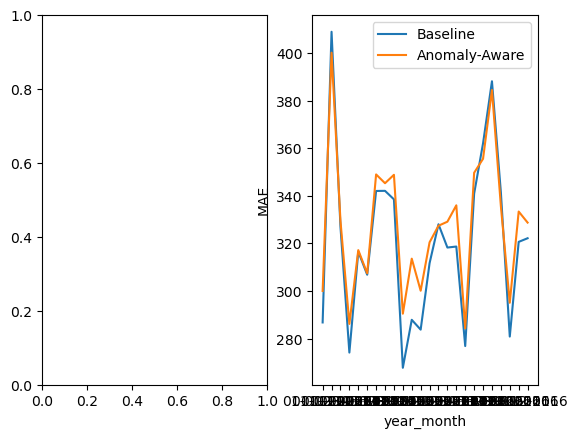

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# MAE
sns.lineplot(
    data=baseline_results['monthly'],
    x='year_month',
    y='MAE',
    label='Baseline',
    ax=axes[0]
)

sns.lineplot(
    data=anomaly_results['monthly'],
    x='year_month',
    y='MAE',
    label='Anomaly-Aware',
    ax=axes[0]
)

axes[0].set_title('Monthly MAE')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

# RMSE
sns.lineplot(
    data=baseline_results['monthly'],
    x='year_month',
    y='RMSE',
    label='Baseline',
    ax=axes[1]
)

sns.lineplot(
    data=anomaly_results['monthly'],
    x='year_month',
    y='RMSE',
    label='Anomaly-Aware',
    ax=axes[1]
)

axes[1].set_title('Monthly RMSE')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()